**Task 1 — Data Loading & Exploration**


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("Housing.csv")

In [9]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [10]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 545
Number of Columns: 13


In [14]:
print("Columns in the dataset:")
print(df.columns)

target = "price"
features = df.drop("price", axis=1).columns

print("Target Column:", target)
print("\nFeature Columns:")
print(features)

Columns in the dataset:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
Target Column: price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [15]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Task 2 — Data Cleaning**

In [19]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Missing Values After Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [20]:
print("Duplicate Rows Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


In [23]:
print("Categorical Columns:")
print(df.select_dtypes(include='object').columns)

df = pd.get_dummies(df, drop_first=True)

print("Dataset Shape After Encoding:", df.shape)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
Dataset Shape After Encoding: (545, 14)


In [25]:
print("Columns Used for Prediction:")
print(df.columns)

df.head()

Columns Used for Prediction:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


**Task 3 — Model Building**

In [26]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop("price", axis=1)
y = df["price"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)


In [27]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Evaluation Metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Performance
-----------------------------
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


In [29]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [30]:
# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation Metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
-------------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [33]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Model Comparison

Two regression models were trained and evaluated: Linear Regression and Random Forest Regressor.

Based on the evaluation metrics, Linear Regression performed better than Random Forest.

- It achieved a lower Mean Absolute Error (MAE).
- It achieved a lower Root Mean Squared Error (RMSE).
- It achieved a higher R² Score (0.653).

Therefore, Linear Regression was selected as the better-performing model for this dataset.

**Task 4 — Visualization (Minimum 3 charts)**


In [34]:
import os

os.makedirs("charts", exist_ok=True)

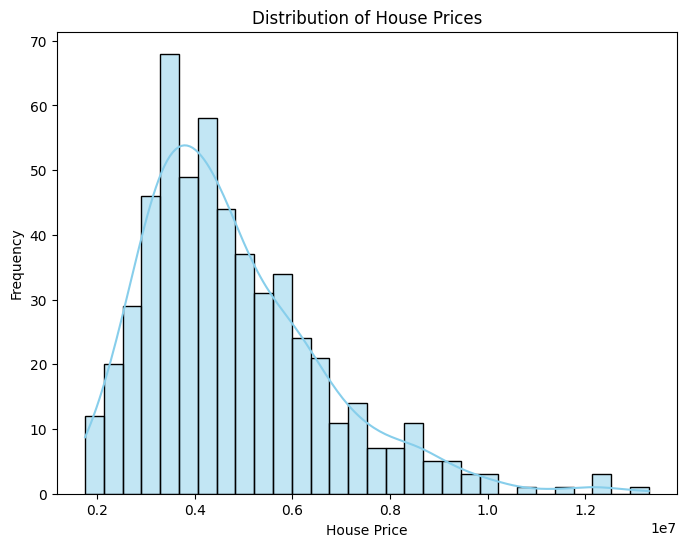

In [35]:
plt.figure(figsize=(8,6))

sns.histplot(df["price"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png", dpi=300)

plt.show()

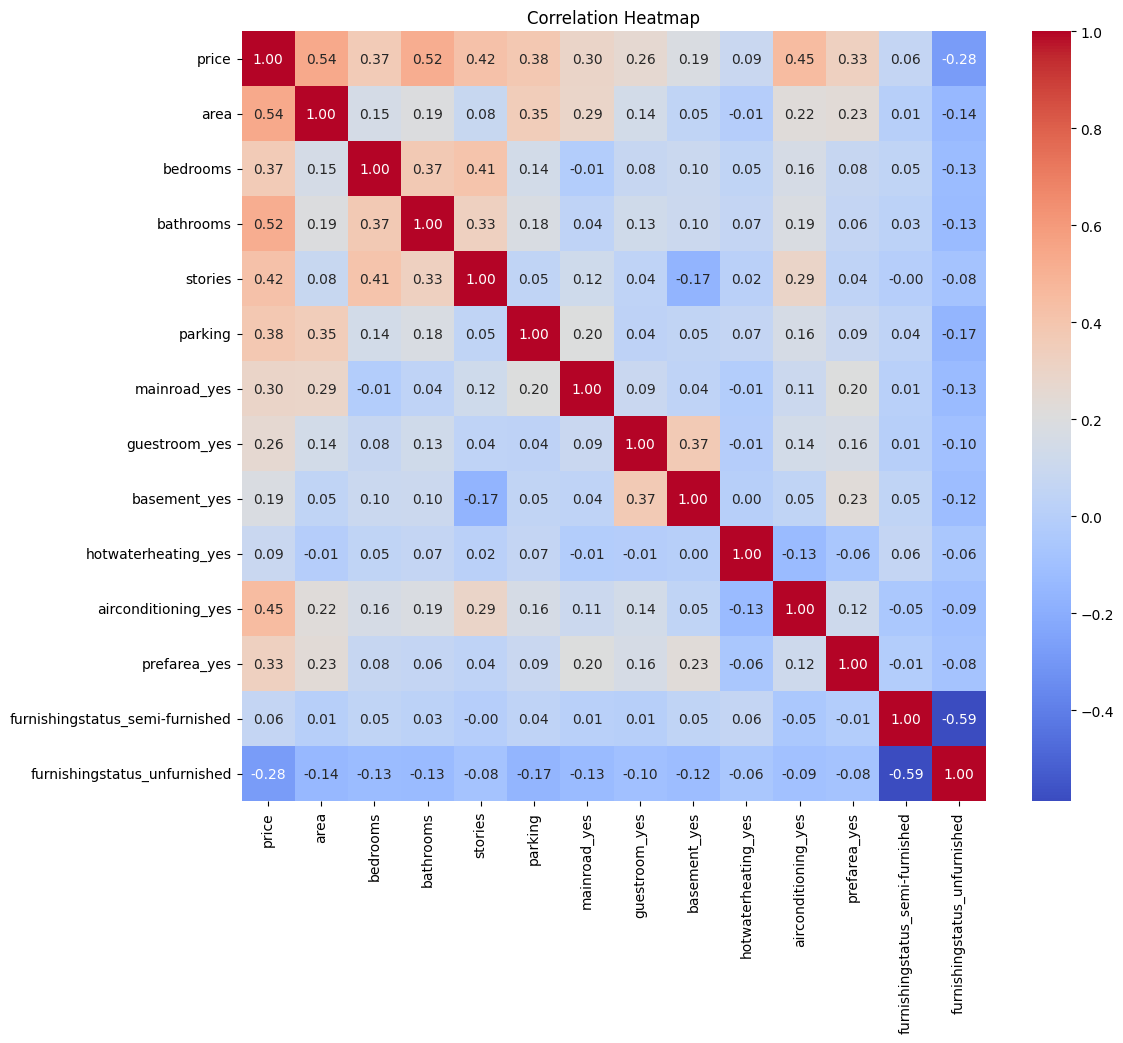

In [36]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png", dpi=300)

plt.show()

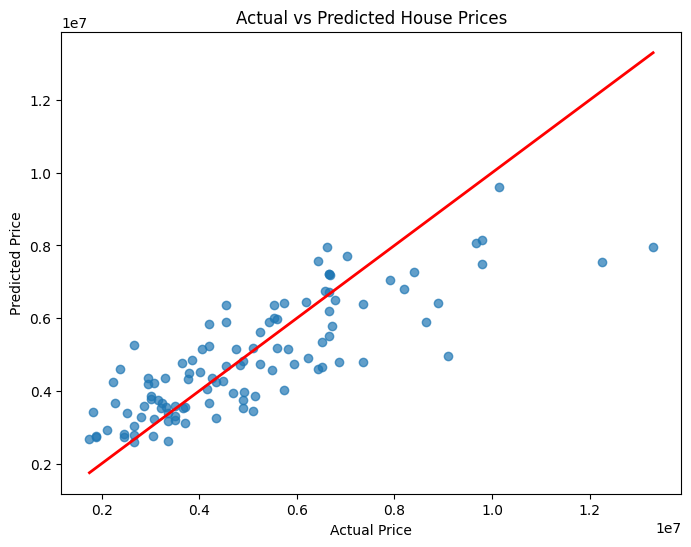

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.savefig("charts/actual_vs_predicted.png", dpi=300)

plt.show()

In [38]:
import os

print("Charts saved successfully!")

print(os.listdir("charts"))

Charts saved successfully!
['price_distribution.png', 'actual_vs_predicted.png', 'correlation_heatmap.png']


In [39]:
# Feature Importance using Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


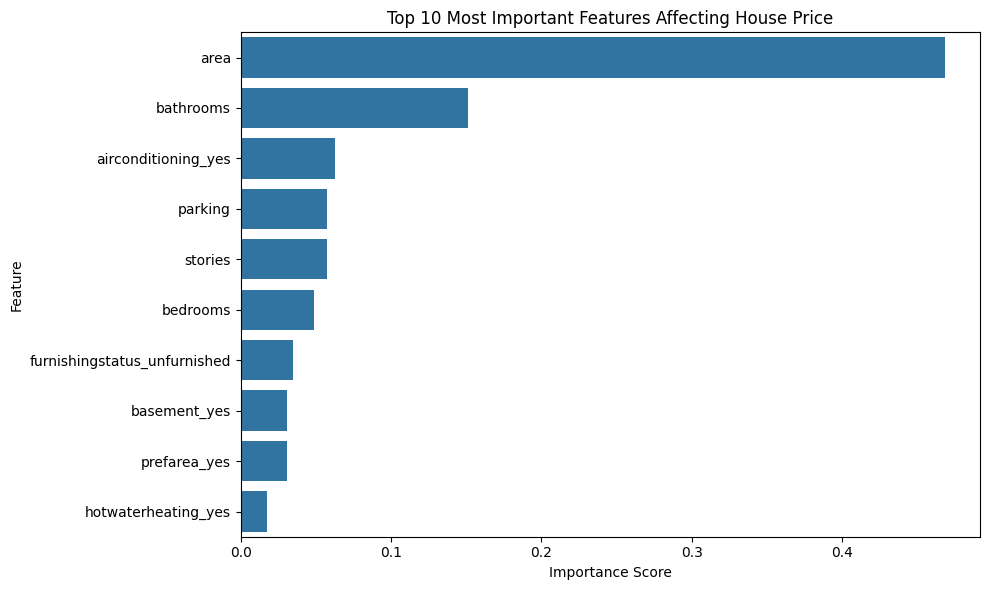

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Most Important Features Affecting House Price")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("charts/feature_importance.png", dpi=300)

plt.show()

## Task 5 – Insights & Summary

### 1. Which features influence house price the most?

The analysis showed that **area**, **bathrooms**, **stories**, **parking**, and **air conditioning** are the most influential features affecting house prices. Houses with larger areas and better amenities generally have higher prices.

---

### 2. How accurate was your model (in plain terms)?

Among the two models tested, **Linear Regression** performed better with an **R² Score of 0.653**. This means the model explains about **65% of the variation in house prices**, making it reasonably accurate for predicting house prices.

---

### 3. What surprised you in the data?

One interesting observation was that the **area of the house** had a much stronger influence on price than some other amenities. Even though facilities like parking and air conditioning increased the price, the size of the property had the greatest impact.

---

### 4. One recommendation for a real estate business based on your findings.

A real estate business should focus on highlighting important features such as **larger area, additional bathrooms, parking availability, and air conditioning** while pricing and marketing properties. Using a machine learning model can also help estimate fair property prices and support better business decisions.
